In [1]:
import os

dataset_path = r"data\Indian Food Images"

foods = os.listdir(dataset_path)

print("Total food classes:", len(foods))
print("\nFirst 20 classes:")
print(foods[:20])

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data\\Indian Food Images'

In [2]:
import os

print(os.getcwd())

C:\Users\sujal\OneDrive\Desktop\Nutrivision-India\notebooks


In [3]:
import os

dataset_path = r"../data/Indian Food Images"

foods = os.listdir(dataset_path)

print("Total food classes:", len(foods))
print("\nFirst 20 classes:")
print(foods[:20])

Total food classes: 1

First 20 classes:
['Indian Food Images']


In [4]:
import os

print(os.listdir("../data/Indian Food Images"))

['Indian Food Images']


In [5]:
import os

dataset_path = r"../data/Indian Food Images/Indian Food Images"

foods = os.listdir(dataset_path)

print("Total food classes:", len(foods))
print(foods[:20])

Total food classes: 80
['adhirasam', 'aloo_gobi', 'aloo_matar', 'aloo_methi', 'aloo_shimla_mirch', 'aloo_tikki', 'anarsa', 'ariselu', 'bandar_laddu', 'basundi', 'bhatura', 'bhindi_masala', 'biryani', 'boondi', 'butter_chicken', 'chak_hao_kheer', 'cham_cham', 'chana_masala', 'chapati', 'chhena_kheeri']


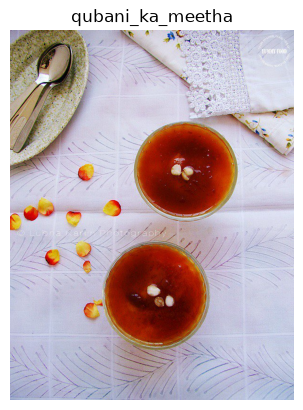

In [6]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = r"../data/Indian Food Images/Indian Food Images"

food_class = random.choice(os.listdir(dataset_path))

food_folder = os.path.join(dataset_path, food_class)

image_file = random.choice(os.listdir(food_folder))

image_path = os.path.join(food_folder, image_file)

img = Image.open(image_path)

plt.imshow(img)
plt.title(food_class)
plt.axis("off")
plt.show()

In [7]:
import torch
print(torch.__version__)
print("GPU Available:", torch.cuda.is_available())

2.12.1+cpu
GPU Available: False


In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../data/Indian Food Images/Indian Food Images",
    transform=transform
)

print("Total Images:", len(dataset))
print("Classes:", len(dataset.classes))

Total Images: 4000
Classes: 80


In [9]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

Training Images: 3200
Validation Images: 800


In [10]:
import torch.nn as nn
from torchvision import models

model = models.mobilenet_v2(weights="DEFAULT")

model.classifier[1] = nn.Linear(
    model.last_channel,
    80
)

print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\sujal/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:02<00:00, 5.24MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
  

In [11]:
import torch

device = torch.device("cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model Ready!")

Model Ready!


In [13]:
model.train()

running_loss = 0

for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

print("Training Loss:", running_loss / len(train_loader))

Training Loss: 1.4030227094888688


In [14]:
# PROPER 10-EPOCH TRAINING LOOP
# Add augmentation + validation accuracy + model saving

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch, torch.nn as nn

# Better transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Reload dataset with better transforms
full_dataset = datasets.ImageFolder(
    root="../data/Indian Food Images/Indian Food Images",
    transform=train_transform
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_set, val_set = torch.utils.data.random_split(
    full_dataset, [train_size, val_size]
)
val_set.dataset.transform = val_transform

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

device = torch.device("cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_acc = 0

for epoch in range(10):
    # Training
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/10 | Loss: {running_loss/len(train_loader):.3f} | Val Acc: {acc:.1f}%")

    # Save best model
    if acc > best_acc:
        best_acc = acc
        torch.save({
            'model_state': model.state_dict(),
            'class_names': full_dataset.classes
        }, "../models/nutrivision_model.pth")
        print(f"  ✅ Model saved! Best accuracy: {best_acc:.1f}%")

print(f"\nTraining complete! Best accuracy: {best_acc:.1f}%")

Epoch 1/10 | Loss: 1.100 | Val Acc: 71.0%
  ✅ Model saved! Best accuracy: 71.0%
Epoch 2/10 | Loss: 0.560 | Val Acc: 74.4%
  ✅ Model saved! Best accuracy: 74.4%
Epoch 3/10 | Loss: 0.325 | Val Acc: 72.2%
Epoch 4/10 | Loss: 0.244 | Val Acc: 70.9%
Epoch 5/10 | Loss: 0.272 | Val Acc: 68.4%
Epoch 6/10 | Loss: 0.241 | Val Acc: 69.8%
Epoch 7/10 | Loss: 0.173 | Val Acc: 69.2%
Epoch 8/10 | Loss: 0.140 | Val Acc: 69.0%
Epoch 9/10 | Loss: 0.130 | Val Acc: 67.0%
Epoch 10/10 | Loss: 0.177 | Val Acc: 62.1%

Training complete! Best accuracy: 74.4%


In [15]:
import os
size = os.path.getsize("../models/nutrivision_model.pth")
print(f"Model file size: {size / 1024 / 1024:.1f} MB")
print("✅ Model saved successfully!")

Model file size: 9.1 MB
✅ Model saved successfully!


Actual food:  poha

Top 3 Predictions:
  poha: 99.8%
  misi_roti: 0.1%
  boondi: 0.1%


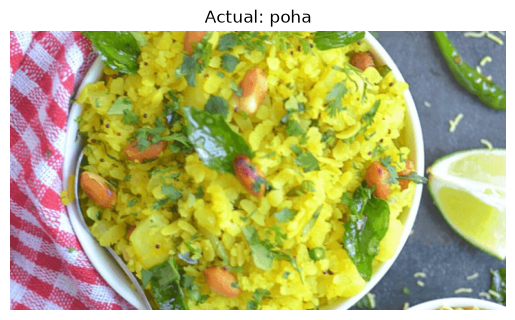

In [16]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import random, os

# Load saved model
checkpoint = torch.load("../models/nutrivision_model.pth", 
                         map_location="cpu")
class_names = checkpoint['class_names']

from torchvision import models
import torch.nn as nn

model_loaded = models.mobilenet_v2(weights=None)
model_loaded.classifier[1] = nn.Linear(
    model_loaded.last_channel, len(class_names))
model_loaded.load_state_dict(checkpoint['model_state'])
model_loaded.eval()

# Pick a random test image
dataset_path = "../data/Indian Food Images/Indian Food Images"
food_class = random.choice(class_names)
folder = os.path.join(dataset_path, food_class)
img_file = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_file)

# Predict
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])
img = Image.open(img_path).convert("RGB")
tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    out = model_loaded(tensor)
    probs = torch.softmax(out, dim=1)
    top3_probs, top3_idx = probs.topk(3)

print(f"Actual food:  {food_class}")
print(f"\nTop 3 Predictions:")
for i in range(3):
    print(f"  {class_names[top3_idx[0][i]]}: "
          f"{top3_probs[0][i]*100:.1f}%")

# Show image
import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Actual: {food_class}")
plt.axis("off")
plt.show()

In [ ]:
import torch
print("Model is saved at: ../models/nutrivision_model.pth")
import os
print("File exists:", os.path.exists("../models/nutrivision_model.pth"))